In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("retail_sales.csv")

In [5]:
df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')

df = df.set_index('Date')

In [7]:
monthly = df['Weekly_Sales'].resample('M').sum() 

C:\Users\Pratham\AppData\Local\Temp\ipykernel_100220\3180645781.py:1: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly = df['Weekly_Sales'].resample('M').sum()


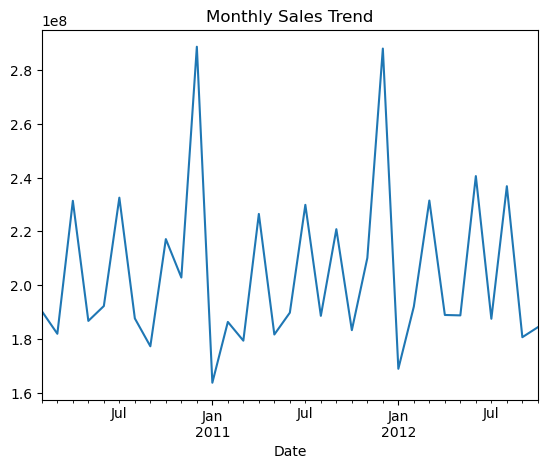

In [8]:
monthly.plot(title="Monthly Sales Trend")
plt.show()


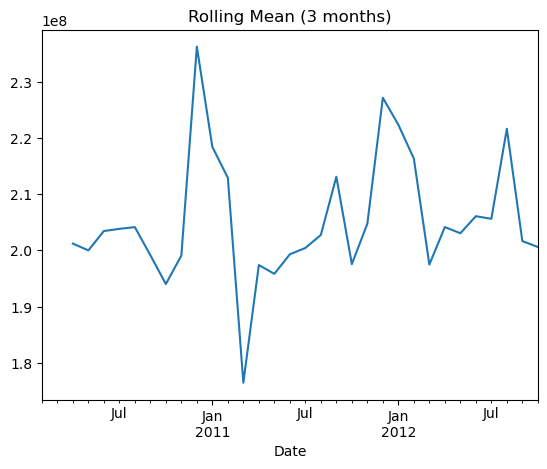

In [9]:
monthly.rolling(window=3).mean().plot(title="Rolling Mean (3 months)")
plt.show()


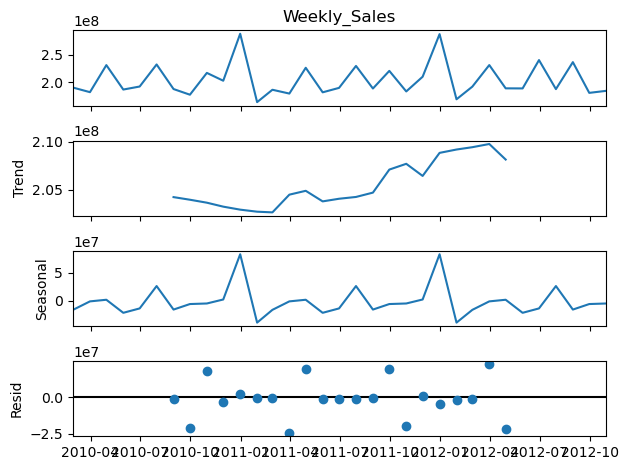

In [10]:
from statsmodels.tsa.seasonal import seasonal_decompose

decomposition = seasonal_decompose(monthly, model='additive')
decomposition.plot()
plt.show()


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(monthly, order=(2,1,2))
result = model.fit()


c:\Users\Pratham\OneDrive\Documents\anaconda\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [13]:
forecast = result.forecast(steps=12)
print(forecast)


2012-11-30    1.971344e+08
2012-12-31    1.962547e+08
2013-01-31    1.957288e+08
2013-02-28    1.952185e+08
2013-03-31    1.947310e+08
2013-04-30    1.942650e+08
2013-05-31    1.938197e+08
2013-06-30    1.933941e+08
2013-07-31    1.929873e+08
2013-08-31    1.925984e+08
2013-09-30    1.922268e+08
2013-10-31    1.918716e+08
Freq: ME, Name: predicted_mean, dtype: float64


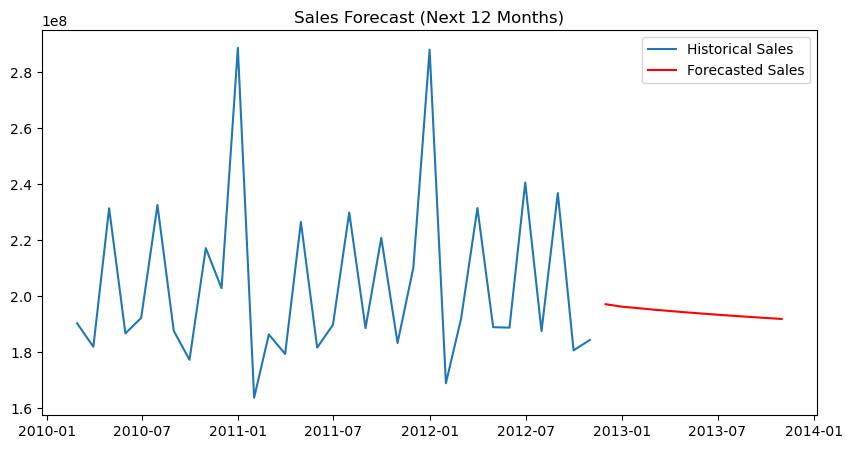

In [14]:
plt.figure(figsize=(10,5))
plt.plot(monthly, label="Historical Sales")
plt.plot(forecast, label="Forecasted Sales", color='red')
plt.legend()
plt.title("Sales Forecast (Next 12 Months)")
plt.show()
